# uji Linear Regression

**Tujuan:** mempelajari regresi linear untuk memperkirakan harga properti berdasarkan karakteristik lokasi dan rumah


- Sumber resmi: https://archive.ics.uci.edu/dataset/477/real+estate+valuation



## 1. Persiapan library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Memuat dataset asli dari UCI




In [2]:
# Mengambil dataset resmi UCI dengan ID 477
dataset = fetch_ucirepo(id=477)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

# Rapikan nama kolom agar lebih mudah dipakai
X.columns = [
    "transaction_date",
    "house_age",
    "distance_to_MRT",
    "convenience_stores",
    "latitude",
    "longitude"
]
y.columns = ["unit_price"]

df = pd.concat([X, y], axis=1)

print("Ukuran dataset:", df.shape)
display(df.head())


Ukuran dataset: (414, 7)


,transaction_date,house_age,distance_to_MRT,convenience_stores,latitude,longitude,unit_price
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 3. Memahami data

Lihat tipe data, ringkasan statistik, dan apakah ada nilai kosong sebelum membuat model


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_date    414 non-null    float64
 1   house_age           414 non-null    float64
 2   distance_to_MRT     414 non-null    float64
 3   convenience_stores  414 non-null    int64  
 4   latitude            414 non-null    float64
 5   longitude           414 non-null    float64
 6   unit_price          414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [4]:
display(df.describe().round(2))


,transaction_date,house_age,distance_to_MRT,convenience_stores,latitude,longitude,unit_price
count,414.00,414.00,414.00,414.00,414.00,414.00,414.00
mean,2013.15,17.71,1083.89,4.09,24.97,121.53,37.98
std,0.28,11.39,1262.11,2.95,0.01,0.02,13.61
min,2012.67,0.00,23.38,0.00,24.93,121.47,7.60
25%,2012.92,9.02,289.32,1.00,24.96,121.53,27.70
50%,2013.17,16.10,492.23,4.00,24.97,121.54,38.45
75%,2013.42,28.15,1454.28,6.00,24.98,121.54,46.60
max,2013.58,43.80,6488.02,10.00,25.01,121.57,117.50


In [5]:
print("Jumlah nilai kosong per kolom:")
display(df.isna().sum())

print("Jumlah baris duplikat:", df.duplicated().sum())


Jumlah nilai kosong per kolom:


transaction_date      0
house_age             0
distance_to_MRT       0
convenience_stores    0
latitude              0
longitude             0
unit_price            0
dtype: int64

Jumlah baris duplikat: 0


## 4. Exploratory Data Analysis (EDA)

Lihat distribusi target dan hubungan sederhana antara beberapa fitur dengan harga per unit area


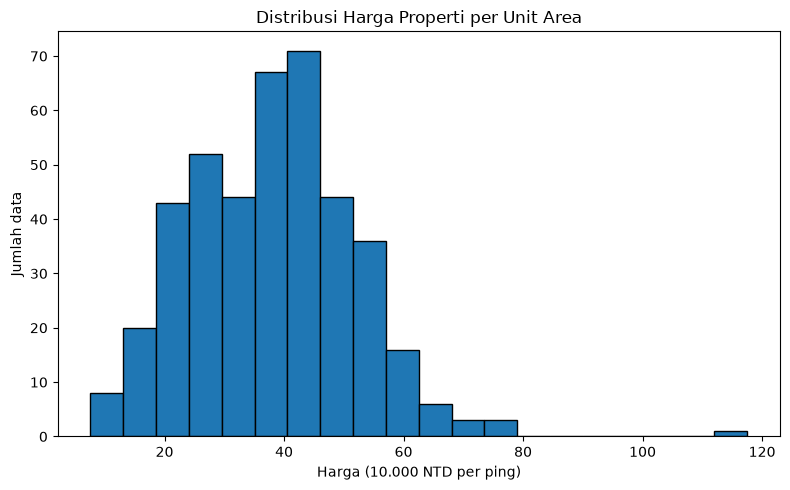

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["unit_price"], bins=20, edgecolor="black")
plt.title("Distribusi Harga Properti per Unit Area")
plt.xlabel("Harga (10.000 NTD per ping)")
plt.ylabel("Jumlah data")
plt.tight_layout()
plt.show()


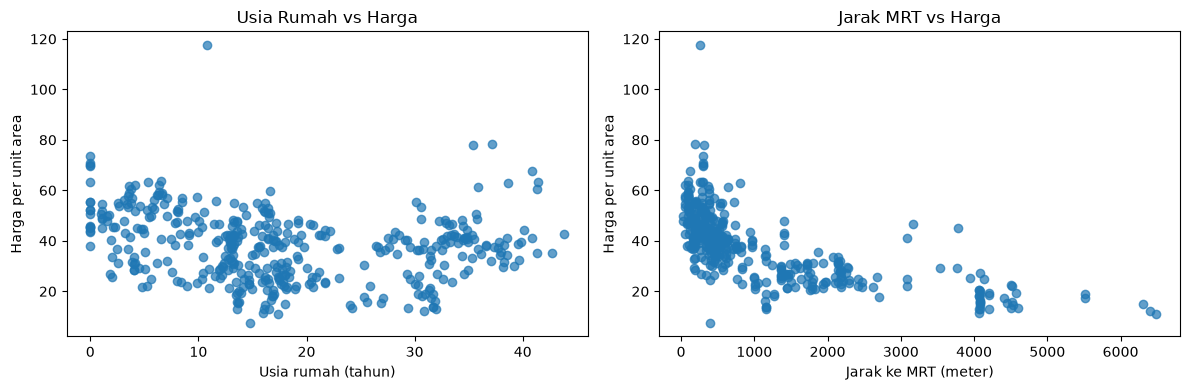

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["house_age"], df["unit_price"], alpha=0.7)
axes[0].set_title("Usia Rumah vs Harga")
axes[0].set_xlabel("Usia rumah (tahun)")
axes[0].set_ylabel("Harga per unit area")

axes[1].scatter(df["distance_to_MRT"], df["unit_price"], alpha=0.7)
axes[1].set_title("Jarak MRT vs Harga")
axes[1].set_xlabel("Jarak ke MRT (meter)")
axes[1].set_ylabel("Harga per unit area")

plt.tight_layout()
plt.show()


## 5. Menyiapkan fitur dan target

- **X** berisi fitur yang digunakan model untuk belajar
- **y** adalah nilai yang ingin diprediksi, yaitu harga per unit area
- `train_test_split` memisahkan data untuk pelatihan dan pengujian
- Kolom nomor ID tidak digunakan sebagai fitur prediksi


In [8]:
X = df.drop(columns=["unit_price"])
y = df["unit_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)


Data training: (331, 6)
Data testing : (83, 6)


## 6. Melatih model Linear Regression

Model mempelajari hubungan linear antara fitur dan target harga


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model berhasil dilatih.")


Model berhasil dilatih.


## 7. Evaluasi model

- **MAE**: rata-rata besar kesalahan absolut prediksi
- **RMSE**: ukuran kesalahan yang memberi penalti lebih besar pada kesalahan besar
- **R²**: seberapa baik model menjelaskan variasi target pada data pengujian. Nilai mendekati 1 umumnya lebih baik, tetapi bukan jaminan model akan bagus pada data baru


In [10]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


MAE  : 5.305
RMSE : 7.315
R²   : 0.681


## 8. Membandingkan harga aktual dan prediksi


In [11]:
hasil = pd.DataFrame({
    "harga_aktual": y_test.values,
    "harga_prediksi": y_pred
})
hasil["selisih"] = hasil["harga_aktual"] - hasil["harga_prediksi"]

display(hasil.head(10).round(2))


,harga_aktual,harga_prediksi,selisih
0,45.1,47.89,-2.79
1,42.3,41.16,1.14
2,52.2,44.27,7.93
3,37.3,40.20,-2.90
4,22.8,27.51,-4.71
5,36.3,45.11,-8.81
6,53.0,44.63,8.37
7,51.4,46.36,5.04
8,16.1,23.62,-7.52
9,59.0,54.33,4.67


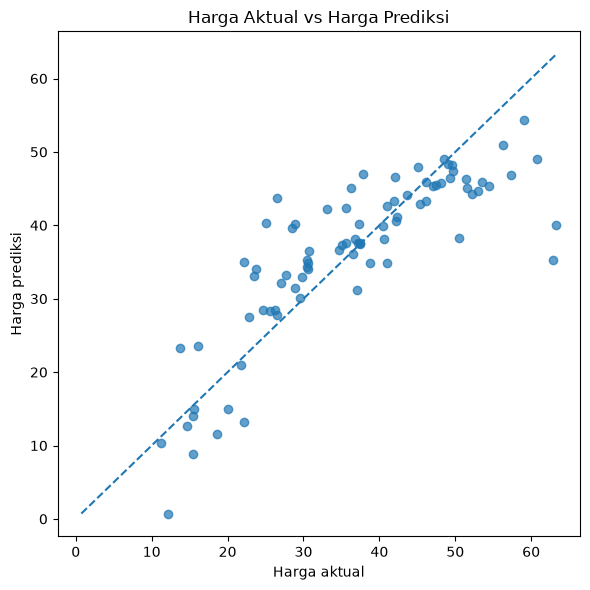

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

batas_min = min(y_test.min(), y_pred.min())
batas_max = max(y_test.max(), y_pred.max())
plt.plot([batas_min, batas_max], [batas_min, batas_max], linestyle="--")

plt.title("Harga Aktual vs Harga Prediksi")
plt.xlabel("Harga aktual")
plt.ylabel("Harga prediksi")
plt.tight_layout()
plt.show()


## 9. Melihat koefisien model

Koefisien menunjukkan arah hubungan linear yang dipelajari model ketika fitur lain dianggap tetap. Jangan langsung menganggapnya sebagai bukti sebab-akibat.


In [13]:
koefisien = pd.DataFrame({
    "fitur": X.columns,
    "koefisien": model.coef_
}).sort_values("koefisien", ascending=False)

display(koefisien.round(4))
print("Intercept:", round(model.intercept_, 4))


,fitur,koefisien
4,latitude,229.0431
0,transaction_date,5.4407
3,convenience_stores,1.0914
2,distance_to_MRT,-0.0048
1,house_age,-0.2708
5,longitude,-29.4926


Intercept: -13044.2319




## Referensi
Yeh, I. (2018). *Real Estate Valuation* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5J30W
